
=== MULTI-REGIME THRESHOLD ANALYSIS: OECD (ADVANCED) ===
Executing SSR grid search and locating local minimums...


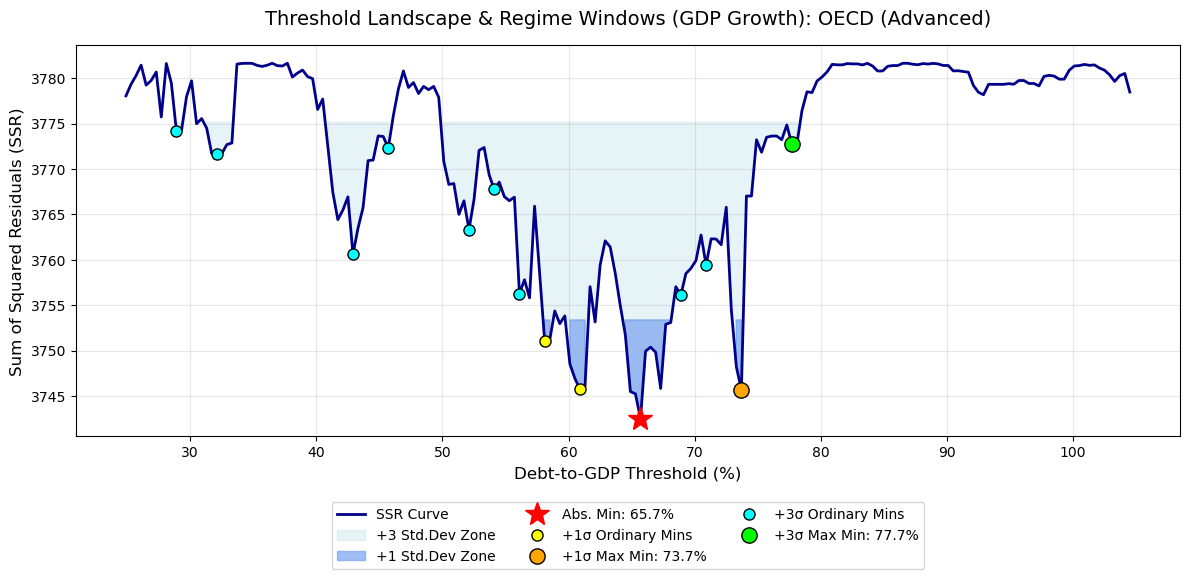


------------------------------------------------------------------------------------------
COUNTRY EXPOSURE ANALYSIS: OECD (Advanced)
------------------------------------------------------------------------------------------

========================= ERA: 1995-2008 (PRE-CRISIS) =========================
                Avg Debt (%)  Avg GDP Growth (%) > Abs Min (65.7%) > Max +1σ (73.7%) > Max +3σ (77.7%)
Country Name                                                                                          
Australia              17.97                3.71                NO                NO                NO
Austria                66.88                2.49               YES                NO                NO
Belgium               107.74                2.37               YES               YES               YES
Canada                 81.80                2.96               YES               YES               YES
Czech Republic         21.31                3.45                NO         

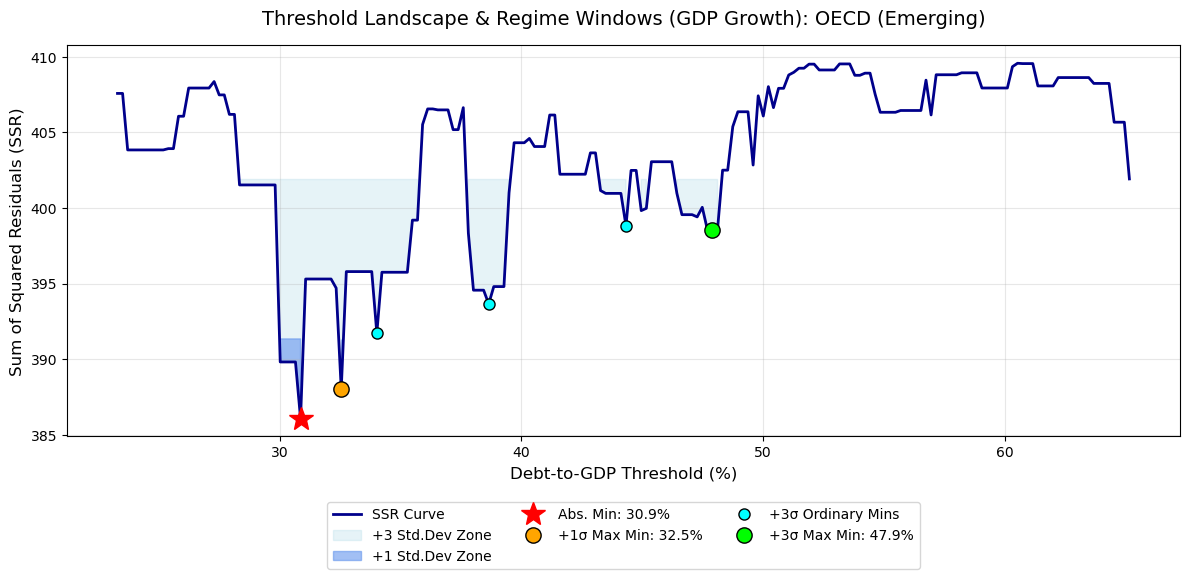


------------------------------------------------------------------------------------------
COUNTRY EXPOSURE ANALYSIS: OECD (Emerging)
------------------------------------------------------------------------------------------

========================= ERA: 1995-2008 (PRE-CRISIS) =========================
              Avg Debt (%)  Avg GDP Growth (%) > Abs Min (30.9%) > Max +1σ (32.5%) > Max +3σ (47.9%)
Country Name                                                                                        
Chile                11.16                5.09                NO                NO                NO
Colombia             35.58                3.06               YES               YES                NO
Hungary              62.92                3.08               YES               YES               YES
Poland               43.12                4.77               YES               YES                NO
Turkey               54.51                5.10               YES               YES     

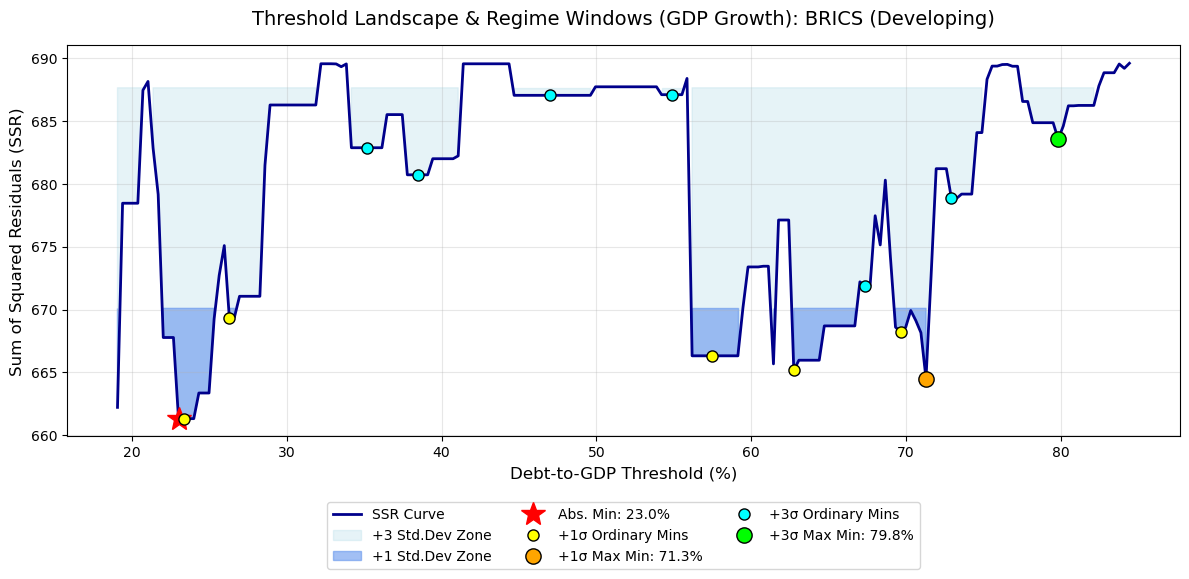


------------------------------------------------------------------------------------------
COUNTRY EXPOSURE ANALYSIS: BRICS (Developing)
------------------------------------------------------------------------------------------

========================= ERA: 1995-2008 (PRE-CRISIS) =========================
                      Avg Debt (%)  Avg GDP Growth (%) > Abs Min (23.0%) > Max +1σ (71.3%) > Max +3σ (79.8%)
Country Name                                                                                                
Brazil                       67.37                3.71               YES                NO                NO
China                        24.04               10.02               YES                NO                NO
Egypt                        83.45                5.14               YES               YES               YES
India                        76.27                6.37               YES               YES                NO
Russia                       41.34  

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from linearmodels.panel import PanelOLS
from scipy.signal import find_peaks
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# ==============================================================================
# 1. LOAD MASTER DATA
# ==============================================================================
PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
master_file = PROCESSED_DIR / "master_panel_data.csv"

# Ensure the processed directory exists
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(master_file)
# Sorting the index is crucial for the era-slicing later
df = df.set_index(['Country Name', 'Year']).sort_index()

BRICS_NATIONS = ["Brazil", "Russia", "India", "China", "Egypt", "United Arab Emirates"]
OECD_EMERGING = ["Chile", "Colombia", "Costa Rica", "Turkey", "Hungary", "Poland"]

def categorize_economy(country):
    if country in BRICS_NATIONS: return 'BRICS (Developing)'
    elif country in OECD_EMERGING: return 'OECD (Emerging)'
    else: return 'OECD (Advanced)'

df['Economic_Bloc'] = [categorize_economy(c) for c, y in df.index]

Y_VAR = 'GDP growth (annual %)'
DEBT_VAR = 'General Government Debt (% of GDP)'
EXOG_VARS = [
    'Gross capital formation (% of GDP)',
    'Inflation (Annual %)',
    'Population growth (annual %)'
]

# ==============================================================================
# 2. LOCAL MINIMUMS & ERA EXPOSURE ALGORITHM
# ==============================================================================
def analyze_threshold_regimes(data, bloc_name):
    print(f"\n{'='*95}")
    print(f"=== MULTI-REGIME THRESHOLD ANALYSIS: {bloc_name.upper()} ===")
    print(f"{'='*95}")
    
    reg_data = data[[Y_VAR, DEBT_VAR] + EXOG_VARS].dropna()
    if len(reg_data) < 30: return
        
    min_debt = reg_data[DEBT_VAR].quantile(0.15)
    max_debt = reg_data[DEBT_VAR].quantile(0.85)
    
    # 200 points for smooth signal processing
    grid = np.linspace(min_debt, max_debt, 200)
    ssr_history = []
    
    print("Executing SSR grid search and locating local minimums...")
    for gamma in grid:
        reg_data['Debt_Low'] = reg_data[DEBT_VAR] * (reg_data[DEBT_VAR] <= gamma)
        reg_data['Debt_High'] = reg_data[DEBT_VAR] * (reg_data[DEBT_VAR] > gamma)
        
        Y = reg_data[Y_VAR]
        X = sm.add_constant(reg_data[['Debt_Low', 'Debt_High'] + EXOG_VARS])
        
        model = PanelOLS(Y, X, entity_effects=True, time_effects=True)
        res = model.fit(cov_type='robust')
        ssr = float(res.resids.squeeze().dot(res.resids.squeeze()))
        ssr_history.append((gamma, ssr))

    gammas = np.array([x[0] for x in ssr_history])
    ssrs = np.array([x[1] for x in ssr_history])
    
    # --- CALCULATE STATISTICAL BOUNDS ---
    best_ssr = np.min(ssrs)
    best_gamma = gammas[np.argmin(ssrs)]
    ssr_std = np.std(ssrs)
    
    bound_1sd = best_ssr + (1 * ssr_std)
    bound_3sd = best_ssr + (3 * ssr_std)
    
    # --- IDENTIFY AND CLASSIFY LOCAL MINIMUMS ---
    # Find all local dips in the SSR curve (peaks of the inverted curve)
    peaks, _ = find_peaks(-ssrs, distance=5) 
    
    # Filter into 1 SD group (excluding the absolute minimum)
    valid_1sd_all = [(gammas[p], ssrs[p]) for p in peaks if ssrs[p] <= bound_1sd and gammas[p] != best_gamma]
    if valid_1sd_all:
        max_1sd = max(valid_1sd_all, key=lambda x: x[0])
        ordinary_1sd = [x for x in valid_1sd_all if x != max_1sd]
    else:
        max_1sd, ordinary_1sd = None, []

    # Filter into 1-to-3 SD group
    valid_3sd_all = [(gammas[p], ssrs[p]) for p in peaks if bound_1sd < ssrs[p] <= bound_3sd and gammas[p] != best_gamma]
    if valid_3sd_all:
        max_3sd = max(valid_3sd_all, key=lambda x: x[0])
        ordinary_3sd = [x for x in valid_3sd_all if x != max_3sd]
    else:
        max_3sd, ordinary_3sd = None, []

    # --- GRAPH 1: SSR LANDSCAPE WITH COLOR-CODED REGIMES ---
    plt.figure(figsize=(12, 6))
    plt.plot(gammas, ssrs, color='darkblue', linewidth=2, label='SSR Curve')
    
    # Highlight Zones
    plt.fill_between(gammas, ssrs, bound_3sd, where=(ssrs <= bound_3sd), 
                     color='lightblue', alpha=0.3, label='+3 Std.Dev Zone')
    plt.fill_between(gammas, ssrs, bound_1sd, where=(ssrs <= bound_1sd), 
                     color='cornflowerblue', alpha=0.6, label='+1 Std.Dev Zone')
    
    # Plot Color-Coded Minimums
    plt.plot(best_gamma, best_ssr, 'r*', markersize=18, label=f'Abs. Min: {best_gamma:.1f}%')
    
    if ordinary_1sd:
        gx, sy = zip(*ordinary_1sd)
        plt.plot(gx, sy, 'o', color='yellow', markersize=8, markeredgecolor='black', label='+1σ Ordinary Mins')
    if max_1sd:
        plt.plot(max_1sd[0], max_1sd[1], 'o', color='orange', markersize=11, markeredgecolor='black', label=f'+1σ Max Min: {max_1sd[0]:.1f}%')
        
    if ordinary_3sd:
        gx, sy = zip(*ordinary_3sd)
        plt.plot(gx, sy, 'o', color='cyan', markersize=8, markeredgecolor='black', label='+3σ Ordinary Mins')
    if max_3sd:
        plt.plot(max_3sd[0], max_3sd[1], 'o', color='lime', markersize=11, markeredgecolor='black', label=f'+3σ Max Min: {max_3sd[0]:.1f}%')

    plt.title(f'Threshold Landscape & Regime Windows (GDP Growth): {bloc_name}', fontsize=14, pad=15)
    plt.xlabel('Debt-to-GDP Threshold (%)', fontsize=12)
    plt.ylabel('Sum of Squared Residuals (SSR)', fontsize=12)
    
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- HISTORICAL TIMELINE MAPPING ---
    # Graph 2 logic remains the same (plotting debt dots vs years)
    
    # --- COUNTRY EXPOSURE TABLES WITH GDP EXPORT ---
    print("\n" + "-"*90)
    print(f"COUNTRY EXPOSURE ANALYSIS: {bloc_name}")
    print("-" * 90)
    
    def generate_era_table(df_era, era_label):
        if df_era.empty: return
        mean_debt = df_era.groupby(level='Country Name')[DEBT_VAR].mean()
        mean_gdp = df_era.groupby(level='Country Name')[Y_VAR].mean()
        
        # Base Table
        table = pd.DataFrame({
            'Avg Debt (%)': mean_debt.round(2),
            'Avg GDP Growth (%)': mean_gdp.round(2)
        })
        
        # Boolean checks against identified thresholds
        table[f'> Abs Min ({best_gamma:.1f}%)'] = (mean_debt > best_gamma).map({True: 'YES', False: 'NO'})
        
        if max_1sd:
            table[f'> Max +1σ ({max_1sd[0]:.1f}%)'] = (mean_debt > max_1sd[0]).map({True: 'YES', False: 'NO'})
        if max_3sd:
            table[f'> Max +3σ ({max_3sd[0]:.1f}%)'] = (mean_debt > max_3sd[0]).map({True: 'YES', False: 'NO'})
        
        print(f"\n{'='*25} ERA: {era_label} {'='*25}")
        print(table.to_string())
        
        # Save to CSV safely
        clean_name = bloc_name.replace(' ', '_').replace('(', '').replace(')', '')
        # Convert "1995-2008 (PRE-CRISIS)" to "1995_2008"
        clean_era = era_label.split()[0].replace('-', '_')
        csv_filename = PROCESSED_DIR / f"Exposure_GDP_{clean_name}_{clean_era}.csv"
        
        table.to_csv(csv_filename)
        print(f"--> Saved data to: {csv_filename}")
        
    era1_data = reg_data.loc[(slice(None), slice(1995, 2008)), :]
    era2_data = reg_data.loc[(slice(None), slice(2009, 2022)), :]
    
    generate_era_table(era1_data, "1995-2008 (PRE-CRISIS)")
    generate_era_table(era2_data, "2009-2022 (POST-CRISIS)")
    print("="*95 + "\n")

# ==============================================================================
# 3. EXECUTE FOR CORE BLOCS
# ==============================================================================
if __name__ == "__main__":
    for bloc in ['OECD (Advanced)', 'OECD (Emerging)', 'BRICS (Developing)']:
        df_bloc = df[df['Economic_Bloc'] == bloc]
        analyze_threshold_regimes(df_bloc, bloc)